# 第 16 章　自編碼器與生成模型 — 實作 Notebook

「醫學生的機器學習入門」深度學習篇第 16 章配套程式（網站：<https://med-study-rpg.com/ml/chapters/16-generative/>）。建議在 **Google Colab** 執行（「執行階段 → 全部執行」）；本機 Jupyter 需安裝 `tensorflow` 與 `keras`。

本 notebook 做一件事：**只給模型看正常心搏，讓它學會「正常長什麼樣」，再用「還原得像不像」來抓異常心搏。**

1. 從 PhysioNet 官方下載 MIT-BIH Arrhythmia Database，切出心搏（和第 14 章同一套程式）
2. **依受試者**切成三組：訓練（只取其中的正常心搏）、驗證（用來定閾值）、測試（全部心搏，含異常）
3. 先用第 10 章的 PCA 做「線性版」的壓縮與還原，當作基準
4. 訓練一個小型自編碼器（autoencoder），以重建誤差當異常分數，選閾值、算敏感度與特異度、AUC
5. 把 8 維的潛在空間畫成 2D；重做一次「隨機切心搏」，看資料洩漏會讓成績虛高多少
6. 延伸實驗（可跳過）：換潛在維度、換隨機種子、換測試折，看結果有多穩定

時間：本機筆電 CPU 實測約 1 分鐘（不含下載）。第 9 節延伸實驗要再訓練 11 個模型，本機約佔 45 秒，Colab 免費 CPU 上較久：**建議開 GPU，也可以跳過**（跳過後其餘各格照常可跑）。

資料：MIT-BIH Arrhythmia Database（Moody & Mark 2001；PhysioNet），授權 Open Data Commons Attribution License v1.0（ODC-By）。本 notebook 的結果僅供學習，不構成臨床建議。

## 0. 環境檢查
印出套件版本並固定隨機種子。Keras 要在 `import` 之前用環境變數指定後端（backend）。沒有 Keras 的環境會跳過自編碼器段落（PCA 基準仍可執行）。

In [1]:
import os
import sys
import time
import json
import zipfile
import hashlib
import urllib.request

import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

# Some numpy builds on macOS (Apple Accelerate) print spurious "encountered in matmul"
# RuntimeWarnings inside PCA; results are unaffected and Colab (Linux) does not show them.
if sys.platform == "darwin":
    import warnings
    warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)

print("numpy", np.__version__, "| pandas", pd.__version__, "| scipy", scipy.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
RS = 42
T_START = time.time()

os.environ["KERAS_BACKEND"] = "tensorflow"   # must be set before importing keras
try:
    import keras
    keras.utils.set_random_seed(RS)          # results may still differ slightly across hardware
    print("keras", keras.__version__, "| backend:", keras.backend.backend())
except ImportError:
    keras = None
    print("Keras is not installed in this environment -> autoencoder sections will be skipped.")
    print("Run this notebook on Google Colab, or `pip install tensorflow keras` locally.")

numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


keras 3.13.2 | backend: tensorflow


## 1. 從官方來源下載原始資料（同第 14 章）

MIT-BIH Arrhythmia Database：48 段、每段 30 分鐘的雙導程 Holter 心電圖，360 Hz，來自 47 位受試者（**record 201 與 202 是同一人**）。依 AAMI 慣例排除 4 段節律器紀錄，剩 44 段、43 位受試者。

下載策略和第 14 章相同：**方案 A** PhysioNet 官方 zip（77 MB，用 zip 內附的 `SHA256SUMS.txt` 檢查）→ **方案 B** 官方網址逐檔下載 → **方案 C** Hugging Face 第三方鏡像（只在官方都失敗時用）。如果你在同一個 Colab 工作階段跑過第 14 章，`data/mitdb.zip` 已存在就不會重抓。（本檔存著的輸出是用先前從 PhysioNet 下載、已比對官方 SHA256 的 zip 執行的，所以顯示 no download needed；你在 Colab 執行時會實際下載。）

In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
ZIP_URL = "https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip"
FILE_URL = "https://physionet.org/files/mitdb/1.0.0/"
HF_URL = ("https://huggingface.co/datasets/epr-labs/mit-bih-arrhythmia-database/"
          "resolve/main/data/train-00000-of-00001.parquet")
ZIP_PATH = os.path.join(DATA_DIR, "mitdb.zip")

# 44 non-paced records (AAMI convention drops paced records 102, 104, 107, 217)
RECORDS = '''100 101 103 105 106 108 109 111 112 113 114 115 116 117 118 119 121 122 123 124
200 201 202 203 205 207 208 209 210 212 213 214 215 219 220 221 222 223 228 230 231 232 233 234'''.split()
SUBJECT = {r: ("201" if r == "202" else r) for r in RECORDS}   # records 201 and 202 = same person


def plan_a_zip():
    """Official PhysioNet zip (77 MB). Returns a function name -> file bytes."""
    if not (os.path.exists(ZIP_PATH) and zipfile.is_zipfile(ZIP_PATH)):   # skip half-downloaded files
        print("downloading the official zip (77 MB) from physionet.org ...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH + ".part")
        os.replace(ZIP_PATH + ".part", ZIP_PATH)
    else:
        print("found", ZIP_PATH, "-> no download needed")
    z = zipfile.ZipFile(ZIP_PATH)
    root = z.namelist()[0].split("/")[0]
    # integrity check: the zip ships its own SHA256SUMS.txt
    sums = dict(line.split()[::-1] for line in z.read(f"{root}/SHA256SUMS.txt").decode().splitlines() if line)
    for r in RECORDS:
        for ext in (".hea", ".dat", ".atr"):
            assert hashlib.sha256(z.read(f"{root}/{r}{ext}")).hexdigest() == sums[r + ext], r + ext
    print("SHA-256 of all", 3 * len(RECORDS), "files match SHA256SUMS.txt")
    return lambda name: z.read(f"{root}/{name}")


def plan_b_files():
    """Official PhysioNet per-file download (132 small requests)."""
    folder = os.path.join(DATA_DIR, "mitdb_files")
    os.makedirs(folder, exist_ok=True)
    for r in RECORDS:
        for ext in (".hea", ".dat", ".atr"):
            path = os.path.join(folder, r + ext)
            if not os.path.exists(path):
                urllib.request.urlretrieve(FILE_URL + r + ext, path + ".part")
                os.replace(path + ".part", path)   # never reuse a half-downloaded file
    print("downloaded", 3 * len(RECORDS), "files from", FILE_URL)
    return lambda name: open(os.path.join(folder, name), "rb").read()

WFDB 格式讀檔器（`.hea` 標頭、`.dat` 訊號、`.atr` 標註），和第 14 章完全相同。**你不需要看懂這一格**，它讀出來的東西和官方 `wfdb` 套件一樣。

In [3]:
BEAT_CODES = {1: "N", 2: "L", 3: "R", 4: "a", 5: "V", 6: "F", 7: "J", 8: "A", 9: "S",
              10: "E", 11: "j", 12: "/", 13: "Q", 34: "e", 38: "f"}   # MIT annotation codes


def read_header(text):
    lines = [l for l in text.splitlines() if l.strip() and not l.startswith("#")]
    n_sig, fs = int(lines[0].split()[1]), float(lines[0].split()[2])
    sigs = []
    for l in lines[1:1 + n_sig]:
        p = l.split()
        sigs.append({"gain": float(p[2].split("/")[0].split("(")[0]), "adc_zero": int(p[4]), "name": p[-1]})
    return n_sig, fs, sigs


def read_212(raw, n_sig):
    b = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 3).astype(np.int16)
    s0 = b[:, 0] | ((b[:, 1] & 0x0F) << 8)          # 12-bit sample 1
    s1 = b[:, 2] | ((b[:, 1] & 0xF0) << 4)          # 12-bit sample 2
    d = np.stack([s0, s1], axis=1).reshape(-1, n_sig)
    d[d > 2047] -= 4096                             # two's complement
    return d


def read_atr(raw):
    w = np.frombuffer(raw, dtype="<u2")
    samples, symbols, t, i = [], [], 0, 0
    while i < len(w):
        code, inc = int(w[i]) >> 10, int(w[i]) & 0x3FF
        if code == 0 and inc == 0:                  # end of file
            break
        if code == 59:                              # SKIP: long time jump
            t += int(np.int32((int(w[i + 1]) << 16) | int(w[i + 2])))
            i += 3
        elif code == 63:                            # AUX: text attached to the previous label
            i += 1 + (inc + 1) // 2
        elif code in (60, 61, 62):                  # NUM / SUB / CHN fields
            i += 1
        else:
            t += inc
            samples.append(t)
            symbols.append(BEAT_CODES.get(code, "?"))   # "?" = non-beat label (rhythm, noise...)
            i += 1
    return np.array(samples), np.array(symbols)


def read_records(get_bytes):
    """Return {record: (fs, MLII signal in mV, annotation samples, annotation symbols)}."""
    out = {}
    for r in RECORDS:
        n_sig, fs, sigs = read_header(get_bytes(r + ".hea").decode())
        k = [s["name"] for s in sigs].index("MLII")       # record 114 stores MLII as the 2nd lead
        dig = read_212(get_bytes(r + ".dat"), n_sig)[:, k]
        samp, sym = read_atr(get_bytes(r + ".atr"))
        out[r] = (fs, (dig - sigs[k]["adc_zero"]) / sigs[k]["gain"], samp, sym)
    return out


def plan_c_mirror():
    """Fallback: third-party Hugging Face mirror of the same raw files (ODC-By); needs pyarrow."""
    import json
    path = os.path.join(DATA_DIR, "mitdb_hf.parquet")
    if not os.path.exists(path):
        urllib.request.urlretrieve(HF_URL, path)
    out = {}
    for _, row in pd.read_parquet(path).iterrows():
        h = json.loads(row["header"])
        if h["record_name"] in RECORDS:
            k = h["sig_name"].index("MLII")
            out[h["record_name"]] = (float(h["fs"]), np.stack(row["signals"])[:, k].astype(float),
                                     np.asarray(row["annotation_sample"]), np.asarray(row["annotation_symbol"]))
    print("loaded from the Hugging Face mirror")
    return out


t0 = time.time()
records = None
for plan in (lambda: read_records(plan_a_zip()), lambda: read_records(plan_b_files()), plan_c_mirror):
    try:
        records = plan()
        break
    except Exception as e:
        print("download plan failed:", repr(e)[:200], "-> trying the next one")
assert records is not None and len(records) == len(RECORDS), (
    "All download plans failed. Check your internet connection, or download the zip manually from "
    "https://physionet.org/content/mitdb/1.0.0/ and put it at data/mitdb.zip")
T_LOAD = time.time() - t0
print(f"{len(records)} records loaded in {T_LOAD:.1f} s (download + reading)")

found data/mitdb.zip -> no download needed


SHA-256 of all 132 files match SHA256SUMS.txt


44 records loaded in 0.7 s (download + reading)


## 2. 切心搏、對應到 AAMI 類別（同第 14 章）

帶通濾波 0.5–40 Hz → 每段紀錄各自標準化 → 以 R 峰為中心切 R 峰前 0.25 秒到後 0.40 秒，每 2 點取 1 點，每個心搏 117 個數字。類別依 AAMI 合併為 N（正常類，**包含束支傳導阻滯**）、S、V、F；Q 類 15 個排除。

In [4]:
AAMI = {**dict.fromkeys("NLRej", "N"), **dict.fromkeys("AaJS", "S"),
        **dict.fromkeys("VE", "V"), "F": "F", **dict.fromkeys("fQ", "Q")}
CLASSES = ["N", "S", "V", "F"]
PRE, POST, STEP = 90, 144, 2          # 0.25 s before / 0.40 s after the R peak at 360 Hz; keep every 2nd point

t0 = time.time()
X, y, groups, n_q = [], [], [], 0
for r, (fs, sig, samp, sym) in records.items():
    assert fs == 360
    b, a = butter(2, [0.5, 40], btype="band", fs=fs)
    sig = filtfilt(b, a, sig)
    sig = (sig - sig.mean()) / sig.std()          # per-record standardisation
    for s, label in zip(samp, sym):
        if label in AAMI and PRE <= s < len(sig) - POST:
            if AAMI[label] == "Q":
                n_q += 1
                continue
            X.append(sig[s - PRE:s + POST:STEP])
            y.append(CLASSES.index(AAMI[label]))
            groups.append(SUBJECT[r])
X = np.array(X, dtype="float32")[..., None]       # (n_beats, 117 time points, 1 channel) for Conv1D
y, groups = np.array(y), np.array(groups)
T_PREP = time.time() - t0

counts = np.bincount(y, minlength=4)
assert counts.sum() == len(y) == len(X)           # class counts add up to the total number of beats
assert len(set(groups)) == 43                     # 44 records, 201 + 202 merged into one subject
print("X shape:", X.shape, f"| prepared in {T_PREP:.1f} s | Q beats excluded: {n_q}")
print(pd.DataFrame({"beats": counts, "percent": (100 * counts / counts.sum()).round(2)}, index=CLASSES))

X shape: (100680, 117, 1) | prepared in 0.5 s | Q beats excluded: 15
   beats  percent
N  90089    89.48
S   2781     2.76
V   7008     6.96
F    802     0.80


## 3. 依受試者切成三組

這一章是**非監督式**的異常偵測：訓練時只給模型看正常心搏（N 類），不給任何異常心搏的標籤。但評估時仍要知道答案，才能算敏感度與特異度。

切法延續第 14 章的教訓——**以受試者為單位**，同一個人只會出現在一組：

- **測試組**：`StratifiedGroupKFold` 的第 1 折，就是第 14 章「切法 B」第 1 折的那 15 位受試者。保留**全部**心搏（含異常），比例不動。
- 剩下 28 位再用 `GroupShuffleSplit` 分成 **訓練組**（約 3/4 的人，只取 N 類心搏來訓練）與 **驗證組**（約 1/4 的人，只用 N 類心搏來**定閾值**）。

閾值用驗證組決定、不碰測試組，測試組只在最後評估一次。

In [5]:
tr, te = next(StratifiedGroupKFold(3, shuffle=True, random_state=RS).split(X, y, groups))
fit_i, val_i = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RS).split(tr, groups=groups[tr]))
fit, val = tr[fit_i], tr[val_i]
S_fit, S_val, S_te = set(groups[fit]), set(groups[val]), set(groups[te])

# no subject in two groups; every beat in exactly one group
assert not (S_fit & S_val) and not (S_fit & S_te) and not (S_val & S_te)
assert len(S_fit) + len(S_val) + len(S_te) == 43
assert len(fit) + len(val) + len(te) == len(y)

fit_n = fit[y[fit] == 0]          # training: normal beats only
val_n = val[y[val] == 0]          # validation: normal beats only, used to set the threshold
is_abn = y[te] != 0               # test: 1 = S/V/F (abnormal), 0 = N
X2 = X[:, :, 0]                   # (n_beats, 117) for PCA and the dense autoencoder

split_table = pd.DataFrame({
    "subjects": [len(S_fit), len(S_val), len(S_te)],
    "beats used": [len(fit_n), len(val_n), len(te)],
    "N": [len(fit_n), len(val_n), int((y[te] == 0).sum())],
    "S": [0, 0, int((y[te] == 1).sum())], "V": [0, 0, int((y[te] == 2).sum())],
    "F": [0, 0, int((y[te] == 3).sum())]},
    index=["train (N only)", "validation (N only)", "test (all beats)"])
assert (split_table[["N", "S", "V", "F"]].sum(axis=1) == split_table["beats used"]).all()
print(split_table)
print("test subjects:", ", ".join(sorted(map(str, S_te))))

                     subjects  beats used      N     S     V    F
train (N only)             21       45184  45184     0     0    0
validation (N only)         7       15407  15407     0     0    0
test (all beats)           15       33421  29498  1463  2072  388
test subjects: 100, 103, 106, 111, 112, 114, 115, 117, 122, 208, 210, 212, 214, 219, 232


## 4. 基準：PCA 也是一種「壓縮＋還原」

第 10 章的主成分分析（PCA）把 117 維的心搏投影到幾個主成分上（壓縮），再用 `inverse_transform` 投影回 117 維（還原）。還原得越不像，代表這個心搏越不符合「訓練資料的主要變化方向」。

這裡用 8 個主成分，和等一下自編碼器的 8 維潛在空間對齊。重建誤差（reconstruction error）定義為每個心搏 117 個點的均方誤差（mean squared error, MSE）。

In [6]:
LATENT = 8
pca = PCA(n_components=LATENT, random_state=RS).fit(X2[fit_n])     # fit on training normal beats only


def pca_error(idx):
    rec = pca.inverse_transform(pca.transform(X2[idx]))
    return np.mean((rec - X2[idx]) ** 2, axis=1)


print(f"variance explained by {LATENT} components: {pca.explained_variance_ratio_.sum():.3f}")
err_val_pca, err_te_pca = pca_error(val_n), pca_error(te)

variance explained by 8 components: 0.915


## 5. 自編碼器：編碼器 → 8 維瓶頸 → 解碼器

自編碼器是一個「輸出要等於輸入」的神經網路。中間故意做一個很窄的瓶頸（bottleneck），逼網路只能用 8 個數字記住一個 117 點的心搏：

- **編碼器（encoder）**：117 → 64 → 32 → 8（壓縮）
- **解碼器（decoder）**：8 → 32 → 64 → 117（還原）

訓練目標就是讓輸出和輸入的 MSE 越小越好，**不需要任何標籤**。如果把所有 ReLU 拿掉、只剩線性層，最佳解會和 PCA 張出同一個子空間；加上非線性之後，它可以學到彎曲的結構。

**選模的揭露**：訓練本身只用正常心搏；但潛在維度 8 是寫作時在 2、4、8、16 之中，用**驗證組受試者的 AUC** 挑的——算 AUC 需要驗證組受試者的異常心搏與標籤。測試組沒有參與**這一步**。但要誠實說明：寫作初期還試過較窄的網路、40 個 epoch 與一維卷積版本，當時也看過它們的測試組 AUC（那些設定沒有放進本 notebook）。看過測試組再決定設定，最後的數字對「沒看過的新病人」會偏樂觀。真實研究的做法是把測試集鎖起來，所有設定都定案後才打開一次。第 9 節的延伸實驗把四種潛在維度在驗證組與測試組的結果都列出來。

In [7]:
EPOCHS = 20


def build_autoencoder(latent=LATENT):
    encoder = keras.Sequential([
        keras.Input(shape=(X2.shape[1],)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(latent),                      # the bottleneck: 8 numbers per beat
    ], name="encoder")
    decoder = keras.Sequential([
        keras.Input(shape=(latent,)),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(X2.shape[1]),                 # back to 117 points
    ], name="decoder")
    ae = keras.Sequential([encoder, decoder], name="autoencoder")
    ae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return encoder, ae


def train_autoencoder(train_idx, val_idx, seed=RS, latent=LATENT):
    keras.utils.set_random_seed(seed)
    encoder, ae = build_autoencoder(latent)
    t = time.time()
    hist = ae.fit(X2[train_idx], X2[train_idx], epochs=EPOCHS, batch_size=256, verbose=0,
                  validation_data=(X2[val_idx], X2[val_idx]))   # input = target: no labels needed
    return encoder, ae, hist, time.time() - t


def ae_error(ae, idx):
    rec = ae.predict(X2[idx], batch_size=4096, verbose=0)
    return np.mean((rec - X2[idx]) ** 2, axis=1)


if keras is not None:
    encoder, ae, hist, t_train = train_autoencoder(fit_n, val_n)
    print(f"parameters: {ae.count_params():,} | trained on {len(fit_n):,} normal beats in {t_train:.1f} s")
    print(f"final MSE  training subjects {hist.history['loss'][-1]:.4f} | "
          f"validation subjects {hist.history['val_loss'][-1]:.4f}")
    err_val_ae, err_te_ae = ae_error(ae, val_n), ae_error(ae, te)
else:
    print("Skipped: Keras is not available.")

parameters: 19,901 | trained on 45,184 normal beats in 3.9 s
final MSE  training subjects 0.0172 | validation subjects 0.0800


注意最後一行：訓練組受試者的 MSE 明顯低於驗證組受試者。模型對「見過的人」的正常心搏還原得特別好，換成沒見過的人就差一截——這正是第 14 章資料洩漏問題的另一面。

### 5.1 看幾個還原的例子
從測試組各挑一個 N、S、V 心搏，畫出原始波形與自編碼器的還原。

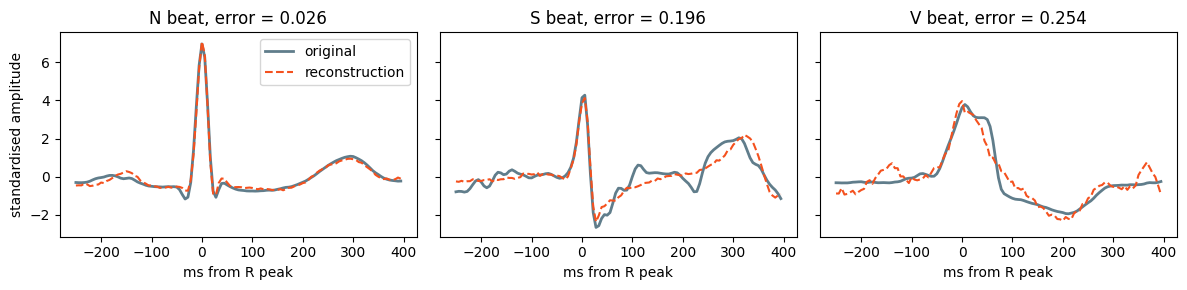

In [8]:
if keras is not None:
    rng = np.random.default_rng(RS)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
    t_ms = (np.arange(X2.shape[1]) * STEP - PRE) / 360 * 1000
    for ax, k in zip(axes, [0, 1, 2]):
        i = rng.choice(np.where(y[te] == k)[0])
        rec = ae.predict(X2[te[i]][None], verbose=0)[0]
        ax.plot(t_ms, X2[te[i]], color="#607D8B", lw=2, label="original")
        ax.plot(t_ms, rec, color="#F4511E", lw=1.5, ls="--", label="reconstruction")
        ax.set_title(f"{CLASSES[k]} beat, error = {err_te_ae[i]:.3f}")
        ax.set_xlabel("ms from R peak")
    axes[0].set_ylabel("standardised amplitude")
    axes[0].legend()
    plt.tight_layout()
    plt.show()

## 6. 重建誤差當異常分數：閾值、敏感度、特異度

重建誤差就是一個「異常分數」：分數越高越可疑。要變成「判異常／判正常」的決定，就需要一個**閾值**（第 11 章的老朋友）。

這裡的做法：取**驗證組正常心搏**重建誤差的第 95 百分位數當閾值，也就是「預期約 5% 的正常心搏會被誤判」，目標特異度約 95%。AUC 則不需要閾值，看的是整體排序能力。

In [9]:
def evaluate(err_val, err_te, q=0.95):
    thr = np.quantile(err_val, q)
    flag = err_te > thr
    out = {"threshold": float(thr), "auc": roc_auc_score(is_abn, err_te),
           "sensitivity": flag[is_abn].mean(), "specificity": (~flag[~is_abn]).mean()}
    for k, c in enumerate(CLASSES[1:], start=1):
        out[f"sens_{c}"] = flag[y[te] == k].mean()
    return out


res = {"PCA (8 components)": evaluate(err_val_pca, err_te_pca)}
if keras is not None:
    res["autoencoder (8-d)"] = evaluate(err_val_ae, err_te_ae)
print(f"test beats: {len(te):,} ({int(is_abn.sum()):,} abnormal, {int((~is_abn).sum()):,} normal)")
print(pd.DataFrame(res).round(3))

test beats: 33,421 (3,923 abnormal, 29,498 normal)
             PCA (8 components)  autoencoder (8-d)
threshold                 0.190              0.246
auc                       0.775              0.783
sensitivity               0.223              0.249
specificity               0.942              0.945
sens_S                    0.019              0.011
sens_V                    0.401              0.458
sens_F                    0.039              0.031


怎麼讀這張表：

- **AUC** 衡量「異常心搏的分數是否普遍高於正常心搏」，0.5 是亂猜。
- 在「目標特異度 95%」的閾值下，**整體敏感度很低**；拆開看，V 類（心室早期收縮，形狀明顯不同）抓到的比例最高，S 類（形狀和正常很像，臨床上主要靠來得太早）幾乎抓不到——和第 14 章的觀察一致：只看單一心搏的形狀，S 類很難。
- 自編碼器和 PCA 的數字很接近。這裡只有一次切分、15 位測試受試者，**兩者的差距未必有意義**；非線性模型不一定贏過線性基準。

### 6.1 誤判集中在誰身上？

In [10]:
err_main = err_te_ae if keras is not None else err_te_pca
thr_main = res["autoencoder (8-d)" if keras is not None else "PCA (8 components)"]["threshold"]
g_te = groups[te]
fp = pd.DataFrame({"subject": g_te[~is_abn], "flagged": err_main[~is_abn] > thr_main})
per_subject = fp.groupby("subject")["flagged"].agg(["size", "mean"]).rename(
    columns={"size": "normal beats", "mean": "false-positive rate"}).sort_values("false-positive rate", ascending=False)
assert per_subject["normal beats"].sum() == int((~is_abn).sum())
print(per_subject.round(3).head(5))
top = per_subject.index[0]
others = fp["subject"] != top
print(f"false positives from subject {top}: {int(fp['flagged'][~others].sum()):,} of {int(fp['flagged'].sum()):,}; "
      f"specificity without this subject: {1 - fp['flagged'][others].mean():.3f}")
fp_pca = err_te_pca[~is_abn] > res["PCA (8 components)"]["threshold"]
pca_top_n = int(fp_pca[g_te[~is_abn] == top].sum())
print(f"PCA: false positives from subject {top}: {pca_top_n:,} of {int(fp_pca.sum()):,}")

         normal beats  false-positive rate
subject                                   
117              1533                0.998
111              2123                0.025
212              2747                0.005
210              2421                0.003
232               398                0.003
false positives from subject 117: 1,530 of 1,619; specificity without this subject: 0.997
PCA: false positives from subject 117: 1,531 of 1,709


大部分誤判（偽陽性）來自**同一位受試者**：他的正常心搏幾乎全部被判為異常，其他人的正常心搏則很少被誤判；PCA 也一樣把這個人整段判為異常，所以問題不在非線性模型，而在這個人的心搏和訓練組的人不像。（第 9 節會看到：換一個測試折，偽陽性的數量與集中程度都不一樣。）模型學到的「正常」，其實是「訓練組那些人的正常」；遇到一位心搏形狀和訓練組差很多的人，就整段報警。這在臨床上很實際：同一份 Holter 被整段標成異常，比零星誤報更容易讓人對系統失去信任。

### 6.2 換閾值：敏感度與特異度的交換

In [11]:
rows = []
for q in [0.80, 0.90, 0.95, 0.99]:
    r = evaluate(err_val_ae if keras is not None else err_val_pca, err_main, q)
    rows.append({"validation percentile": q, "threshold": r["threshold"],
                 "sensitivity": r["sensitivity"], "specificity": r["specificity"], "sens_V": r["sens_V"]})
tradeoff = pd.DataFrame(rows)
print(tradeoff.round(3).to_string(index=False))

 validation percentile  threshold  sensitivity  specificity  sens_V
                  0.80      0.099        0.604        0.779   0.874
                  0.90      0.198        0.350        0.935   0.636
                  0.95      0.246        0.249        0.945   0.458
                  0.99      0.495        0.028        0.959   0.048


閾值往下調，抓到的異常變多，但被誤判的正常心搏也變多。閾值該放哪裡，取決於臨床用途：篩檢想少漏掉（敏感度優先），還是不想讓護理站一直響（特異度優先）。

下圖是測試組重建誤差的分布（橫軸取 log10，因為誤差跨好幾個數量級），虛線是閾值。

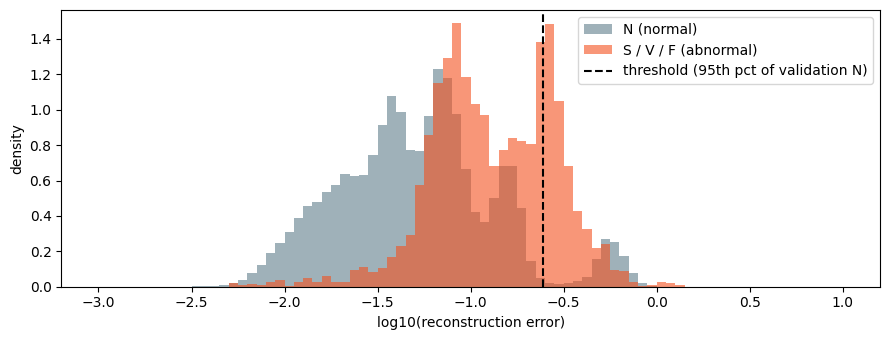

In [12]:
bins = np.linspace(-3, 1, 81)        # log10(error) from 0.001 to 10
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(np.log10(err_main[~is_abn]), bins=bins, density=True, alpha=0.6, color="#607D8B", label="N (normal)")
ax.hist(np.log10(err_main[is_abn]), bins=bins, density=True, alpha=0.6, color="#F4511E", label="S / V / F (abnormal)")
ax.axvline(np.log10(thr_main), color="black", ls="--", label="threshold (95th pct of validation N)")
ax.set_xlabel("log10(reconstruction error)")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

## 7. 潛在空間：8 個數字裡裝了什麼？

編碼器把每個心搏壓成 8 個數字，這 8 維就是潛在空間（latent space）。8 維畫不出來，所以再用 PCA 投影到 2 維（只用訓練組的潛在向量來決定投影方向）。每一點是一個測試組心搏。

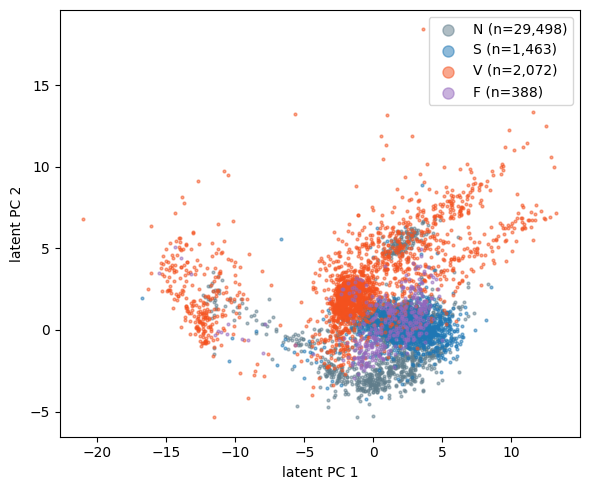

In [13]:
if keras is not None:
    z_fit = encoder.predict(X2[fit_n], batch_size=4096, verbose=0)
    z_te = encoder.predict(X2[te], batch_size=4096, verbose=0)
    proj = PCA(n_components=2, random_state=RS).fit(z_fit)
    z2 = proj.transform(z_te)
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = ["#607D8B", "#1f77b4", "#F4511E", "#9467bd"]
    for k in range(4):
        idx = np.where(y[te] == k)[0]
        idx = idx[:: max(1, len(idx) // 1500)]          # at most ~1,500 points per class
        ax.scatter(z2[idx, 0], z2[idx, 1], s=4, alpha=0.5, color=colors[k], label=f"{CLASSES[k]} (n={int((y[te] == k).sum()):,})")
    ax.set_xlabel("latent PC 1")
    ax.set_ylabel("latent PC 2")
    ax.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

V 類有一大片落在正常心搏聚集區之外；S 類大多和 N 疊在一起。模型從沒看過任何異常心搏、也沒有看過任何標籤，潛在空間裡的這些結構完全是「學還原正常心搏」順便學到的。

## 8. 對照：如果隨機切心搏呢？

把同一個自編碼器改用第 14 章的「切法 A」：所有心搏打散後隨機切，訓練與驗證的正常心搏數量和上面相同。**同一個人的正常心搏同時出現在訓練與測試。**

In [14]:
if keras is not None:
    r_tr, r_te = next(StratifiedKFold(3, shuffle=True, random_state=RS).split(X, y))
    r_n = np.random.default_rng(RS).permutation(r_tr[y[r_tr] == 0])
    r_fit, r_val = r_n[:len(fit_n)], r_n[len(fit_n):len(fit_n) + len(val_n)]
    assert len(set(groups[r_te]) - set(groups[r_fit])) == 0      # every test subject was seen in training
    _, ae_r, _, _ = train_autoencoder(r_fit, r_val)
    err_r = ae_error(ae_r, r_te)
    thr_r = np.quantile(ae_error(ae_r, r_val), 0.95)
    abn_r = y[r_te] != 0
    res_random = {"auc": roc_auc_score(abn_r, err_r), "sensitivity": (err_r[abn_r] > thr_r).mean(),
                  "specificity": (err_r[~abn_r] <= thr_r).mean()}
    cmp = pd.DataFrame({"by subject (main)": {k: res["autoencoder (8-d)"][k] for k in res_random},
                        "random beats (leaky)": res_random})
    print(cmp.round(3))
    comp_main, comp_random = np.bincount(y[te], minlength=4).tolist(), np.bincount(y[r_te], minlength=4).tolist()
    print("test-set class counts N/S/V/F  by subject:", comp_main, "| random beats:", comp_random)

             by subject (main)  random beats (leaky)
auc                      0.783                 0.955
sensitivity              0.249                 0.854
specificity              0.945                 0.950
test-set class counts N/S/V/F  by subject: [29498, 1463, 2072, 388] | random beats: [30030, 927, 2336, 267]


隨機切心搏時，AUC 與敏感度都高出一大截。主因和第 14 章相同：測試組的每個人在訓練時都出現過，模型早就記住「這個人的正常長什麼樣」，所以這個人的異常心搏特別顯眼。**這個高分不代表模型對新病人有用**。要注意兩組測試心搏的類別組成不同（隨機切的 V 較多、S 較少，而 V 本來就比較好抓），所以差距有一部分來自組成；這個對照也只跑了一個種子。

## 9. 延伸實驗（建議開 GPU，可跳過）：結果有多穩定？

這一節要再訓練 11 個模型；跳過的話，第 10 節仍可執行，只是不會輸出延伸實驗的數字。

上面所有數字都來自**一次切分（第 1 折）、一個隨機種子（42）、一個潛在維度（8）**。這一節把這三件事各換一換。

### 9.1 換潛在維度（第 1 折、種子 42）
同時列出驗證組 AUC（選模的依據，需要驗證組受試者的異常標籤）與測試組 AUC。PCA 也用同樣的維度做一次。

In [15]:
def val_test_auc(err_fn):
    """AUC on all validation-subject beats and on all test beats."""
    return roc_auc_score(y[val] != 0, err_fn(val)), roc_auc_score(is_abn, err_fn(te))


def pca_err_fn(p):
    return lambda idx: np.mean((p.inverse_transform(p.transform(X2[idx])) - X2[idx]) ** 2, axis=1)


sweep = []
if keras is not None:
    for lat in [2, 4, 8, 16]:
        ae_l = ae if lat == LATENT else train_autoencoder(fit_n, val_n, latent=lat)[1]   # 8-d is the main model
        a_val, a_te = val_test_auc(lambda idx: ae_error(ae_l, idx))
        p_val, p_te = val_test_auc(pca_err_fn(PCA(n_components=lat, random_state=RS).fit(X2[fit_n])))
        sweep.append({"latent": lat, "AE val AUC": a_val, "AE test AUC": a_te, "PCA val AUC": p_val, "PCA test AUC": p_te})
    sweep = pd.DataFrame(sweep)
    print(sweep.round(3).to_string(index=False))
    print("chosen by AE validation AUC:", int(sweep.loc[sweep["AE val AUC"].idxmax(), "latent"]),
          "| highest AE test AUC:", int(sweep.loc[sweep["AE test AUC"].idxmax(), "latent"]))

 latent  AE val AUC  AE test AUC  PCA val AUC  PCA test AUC
      2       0.692        0.847        0.702         0.830
      4       0.744        0.859        0.800         0.710
      8       0.792        0.783        0.720         0.775
     16       0.754        0.813        0.746         0.761
chosen by AE validation AUC: 8 | highest AE test AUC: 4


主結果用的 8 維是驗證組 AUC 最高的；但在測試組上，8 維**不是**最好的。這正是不能拿測試組挑模型的原因：看著測試組挑，就會挑到測試組上運氣最好的那個，報出來的成績偏樂觀。

### 9.2 換隨機種子、換測試折（8 維）
三個測試折 × 三個種子，共 9 個模型（第 1 折種子 42 就是主結果）。每一折都照主結果的方式切訓練／驗證組，以驗證組正常心搏的第 95 百分位數當閾值。

In [16]:
SEEDS = [42, 1, 2]
folds = list(StratifiedGroupKFold(3, shuffle=True, random_state=RS).split(X, y, groups))
robust = []
if keras is not None:
    for k, (tr_k, te_k) in enumerate(folds):
        fi, vi = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RS).split(tr_k, groups=groups[tr_k]))
        fit_k, val_k = tr_k[fi], tr_k[vi]
        assert not (set(groups[fit_k]) & set(groups[te_k])) and not (set(groups[val_k]) & set(groups[te_k]))
        assert not (set(groups[fit_k]) & set(groups[val_k]))
        fitn_k, valn_k, abn_k = fit_k[y[fit_k] == 0], val_k[y[val_k] == 0], y[te_k] != 0
        pca_auc = roc_auc_score(abn_k, pca_err_fn(PCA(n_components=LATENT, random_state=RS).fit(X2[fitn_k]))(te_k))
        for seed in SEEDS:
            ae_k = ae if (k == 0 and seed == RS) else train_autoencoder(fitn_k, valn_k, seed=seed)[1]
            e_te, thr_k = ae_error(ae_k, te_k), np.quantile(ae_error(ae_k, valn_k), 0.95)
            flag = e_te > thr_k
            fp_subj = pd.Series(groups[te_k][~abn_k][flag[~abn_k]]).value_counts()
            robust.append({"fold": k + 1, "seed": seed, "AUC": roc_auc_score(abn_k, e_te), "PCA AUC": pca_auc,
                           "sens": flag[abn_k].mean(), "spec": (~flag[~abn_k]).mean(),
                           "sens_S": flag[y[te_k] == 1].mean(), "sens_V": flag[y[te_k] == 2].mean(),
                           "FP": int(flag[~abn_k].sum()), "top FP subject": str(fp_subj.index[0]),
                           "top FP share": fp_subj.iloc[0] / fp_subj.sum()})
    robust = pd.DataFrame(robust)
    assert len(robust) == 3 * len(SEEDS)
    print(robust.round(3).to_string(index=False))
    print("\nrange over all 9 models [min, max]:")
    for c in ["AUC", "sens", "spec", "sens_S", "sens_V"]:
        print(f"  {c}: [{robust[c].min():.3f}, {robust[c].max():.3f}]")
    f1 = robust[robust["fold"] == 1]
    print("fold 1 only (3 seeds): " + " | ".join(f"{c} [{f1[c].min():.3f}, {f1[c].max():.3f}]" for c in ["AUC", "sens", "sens_V"]))
    print("AE AUC minus PCA AUC per fold (seed 42):",
          [round(float(r["AUC"] - r["PCA AUC"]), 3) for _, r in robust[robust["seed"] == RS].iterrows()])

 fold  seed   AUC  PCA AUC  sens  spec  sens_S  sens_V   FP top FP subject  top FP share
    1    42 0.783    0.775 0.249 0.945   0.011   0.458 1619            117         0.945
    1     1 0.760    0.775 0.344 0.939   0.018   0.629 1812            117         0.845
    1     2 0.859    0.775 0.427 0.940   0.137   0.699 1782            117         0.860
    2    42 0.840    0.823 0.338 0.992   0.291   0.360  266            231         0.541
    2     1 0.840    0.823 0.390 0.970   0.321   0.421 1011            231         0.823
    2     2 0.846    0.823 0.385 0.983   0.313   0.416  565            231         0.781
    3    42 0.828    0.792 0.120 0.987   0.030   0.151  346            207         0.277
    3     1 0.835    0.792 0.217 0.985   0.037   0.278  409            222         0.323
    3     2 0.836    0.792 0.207 0.980   0.056   0.261  543            222         0.262

range over all 9 models [min, max]:
  AUC: [0.760, 0.859]
  sens: [0.120, 0.427]
  spec: [0.939, 0.992]
  sen

怎麼讀：

- 只換隨機種子，敏感度與 V 類敏感度就會跳動；所以「抓到幾成」要看範圍，不要只看一個數字。
- `top FP share` 是偽陽性中來自「誤判最多的那位受試者」的比例。第 1 折（受試者 117）誤判多且集中；第 2 折也有一半以上來自單一受試者，但誤判總數少得多；第 3 折較分散。
- 每一折自編碼器與 PCA 的 AUC 差距都要和種子造成的跳動一起看。

## 10. 整理結果

下一格把關鍵數字整理成一行機器可讀的 JSON（網站的圖與互動 demo 由 `scripts/figs_ch16.py` 讀這一行並核對）。

In [17]:
if keras is not None:
    hist_counts = {c: np.histogram(np.log10(err_main[y[te] == k]), bins=bins)[0].tolist() for k, c in enumerate(CLASSES)}
    assert sum(sum(v) for v in hist_counts.values()) == len(te)   # every test beat falls inside the bins
    summary = {
        "subjects": {"train": len(S_fit), "val": len(S_val), "test": len(S_te)},
        "beats": {"train_n": len(fit_n), "val_n": len(val_n), "test": len(te), "test_abnormal": int(is_abn.sum())},
        "params": ae.count_params(),
        "ae": {k: round(float(v), 4) for k, v in res["autoencoder (8-d)"].items()},
        "pca": {k: round(float(v), 4) for k, v in res["PCA (8 components)"].items()},
        "pca_var": round(float(pca.explained_variance_ratio_.sum()), 4),
        "random": {k: round(float(v), 4) for k, v in res_random.items()},
        "tradeoff": tradeoff.round(4).to_dict(orient="records"),
        "fp_top_subject": str(top), "spec_without_top": round(float(1 - fp["flagged"][others].mean()), 4),
        "fp_total": int(fp["flagged"].sum()), "fp_top_n": int(fp["flagged"][~others].sum()),
        "pca_fp_total": int(fp_pca.sum()), "pca_fp_top_n": pca_top_n,
        "train_mse": round(float(hist.history["loss"][-1]), 4), "val_mse": round(float(hist.history["val_loss"][-1]), 4),
        "comp_main": comp_main, "comp_random": comp_random,

        "hist_bins": bins.round(3).tolist(), "hist_counts": hist_counts,
    }
    if "sweep" in globals() and "robust" in globals():          # section 9 was run
        summary["sweep"] = sweep.round(4).to_dict(orient="records")
        summary["robust"] = robust.round(4).to_dict(orient="records")
    else:
        print("Section 9 (extra experiments) was skipped: its numbers are not included below.")
    print("RESULTS_JSON", json.dumps(summary))

RESULTS_JSON {"subjects": {"train": 21, "val": 7, "test": 15}, "beats": {"train_n": 45184, "val_n": 15407, "test": 33421, "test_abnormal": 3923}, "params": 19901, "ae": {"threshold": 0.246, "auc": 0.7827, "sensitivity": 0.249, "specificity": 0.9451, "sens_S": 0.0109, "sens_V": 0.458, "sens_F": 0.0309}, "pca": {"threshold": 0.1896, "auc": 0.7748, "sensitivity": 0.2228, "specificity": 0.9421, "sens_S": 0.0191, "sens_V": 0.4011, "sens_F": 0.0387}, "pca_var": 0.9149, "random": {"auc": 0.9552, "sensitivity": 0.8541, "specificity": 0.9501}, "tradeoff": [{"validation percentile": 0.8, "threshold": 0.0992, "sensitivity": 0.6044, "specificity": 0.7788, "sens_V": 0.874}, {"validation percentile": 0.9, "threshold": 0.1977, "sensitivity": 0.35, "specificity": 0.9345, "sens_V": 0.6361}, {"validation percentile": 0.95, "threshold": 0.246, "sensitivity": 0.249, "specificity": 0.9451, "sens_V": 0.458}, {"validation percentile": 0.99, "threshold": 0.4947, "sensitivity": 0.0275, "specificity": 0.9591, "

In [18]:
print(f"total notebook time: {time.time() - T_START:.1f} s (download + reading {T_LOAD:.1f} s)")

total notebook time: 55.9 s (download + reading 0.7 s)


## 11. 動手試試

1. **改潛在維度**：把 `LATENT` 改成 2 或 16，重跑第 4 節之後的所有格子。瓶頸越窄，正常心搏的還原越差；AUC 會怎麼變？
2. **換閾值**：在 `evaluate` 裡把 `q` 改成 0.90 或 0.99，對照第 6.2 節的表格，找出你覺得「適合 Holter 篩檢」的點，並說明理由。
3. **只用「真正正常」的心搏訓練**：AAMI 的 N 類包含左右束支傳導阻滯的心搏（符號 L、R）。在第 2 節多記一個 `symbols` 清單，訓練時只用符號為 `N` 的心搏，看束支傳導阻滯的受試者在測試組會不會變成大量偽陽性。
4. **換成一維卷積自編碼器**：把編碼器前兩層換成 `Reshape((117, 1))`、`Conv1D(16, 7, padding="same", activation="relu")`、`MaxPooling1D(3)`、`Flatten()`，比較 AUC。結果不一定比較好——記得只換種子成績也會跳動。

## 參考資料

- Moody GB, Mark RG. The impact of the MIT-BIH Arrhythmia Database. *IEEE Eng Med Biol Mag* 2001;20(3):45–50.
- Goldberger AL, et al. PhysioBank, PhysioToolkit, and PhysioNet. *Circulation* 2000;101(23):e215–e220.
- Hinton GE, Salakhutdinov RR. Reducing the dimensionality of data with neural networks. *Science* 2006;313(5786):504–507.
- MIT-BIH Arrhythmia Database v1.0.0：<https://physionet.org/content/mitdb/1.0.0/>（ODC-By v1.0）